> Benjamin Nikholas

> Data Science / JCSDOL-014

> Modul 2 - Tugas 33

> 3 Juli 2024
---
---

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = 10, 6
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, r2_score

In [43]:
df = sns.load_dataset('mpg')
df.dropna(inplace = True)
df.reset_index(drop = True)
display(df)
df.info()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


Independen variabel : Horsepower

Dependen variabel : mpg

In [45]:
# Analisa korelasi antara Horse Power dan MPG
correlation = df['horsepower'].corr(df['mpg'])
print(f'Korelasi antara Horse Power dan MPG: {correlation:.2f}')

Korelasi antara Horse Power dan MPG: -0.78


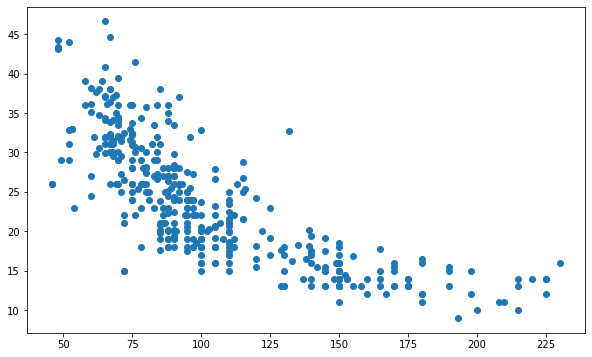

In [17]:
plt.scatter(df.horsepower,
            df.mpg)
plt.show()

In [41]:
model = LinearRegression()
X = df[['horsepower']]
y = df.mpg

model.fit(X, y)

intercept = model.intercept_
slope = model.coef_[0]

print(f'Intercept: {intercept:.2f}')
print(f'Slope: {slope:.2f}')

Intercept: 39.94
Slope: -0.16


In [34]:
y_pred = model.predict(X)

mse = mean_absolute_percentage_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f'Mean Absolute Percentage Error (MAPE): {mse:.2f}')
print(f'R^2 Score: {r2:.2f}')

Mean Absolute Percentage Error (MAPE): 0.18
R^2 Score: 0.61


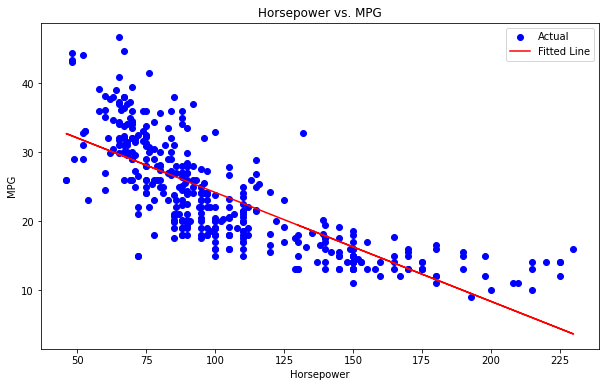

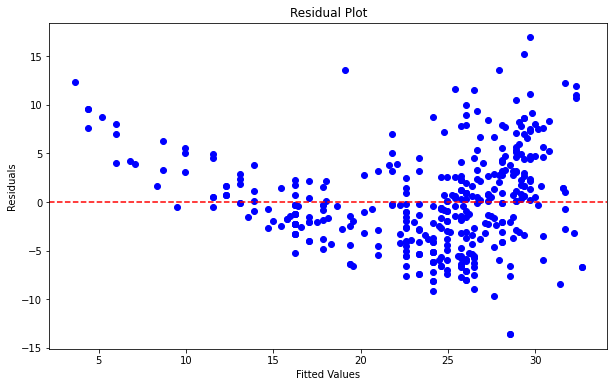

In [36]:
# Plot hasil regresi linier
plt.scatter(X, y, color='blue', label='Actual')
plt.plot(X, y_pred, color='red', label='Fitted Line')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.title('Horsepower vs. MPG')
plt.legend()
plt.show()

# Residual plot
residuals = y - y_pred
plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y = 0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()